In [8]:
import os
import rasterio
import matplotlib.pyplot as plt
import numpy as np 


In [3]:
samples = sorted(os.listdir("samples"))
labels = sorted(os.listdir("labels"))

print(samples[0], labels[0])

S2A_MSIL2A_20171025T150721_N0500_R082_T19QGA_20230910T203157.SAFE_img_0.tiff S2A_MSIL2A_20171025T150721_N0500_R082_T19QGA_20230910T203157.SAFE_ndvi_0.tiff


c:\Users\dr274\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\rasterio\__init__.py:379: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


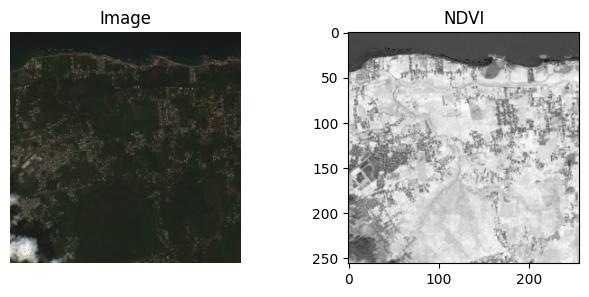

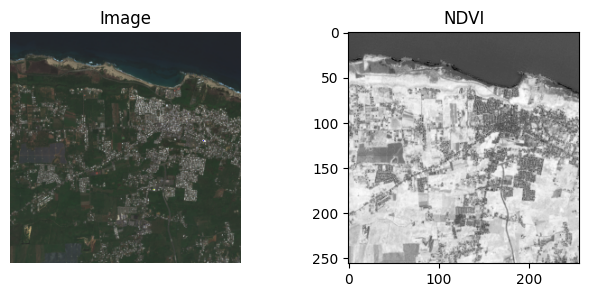

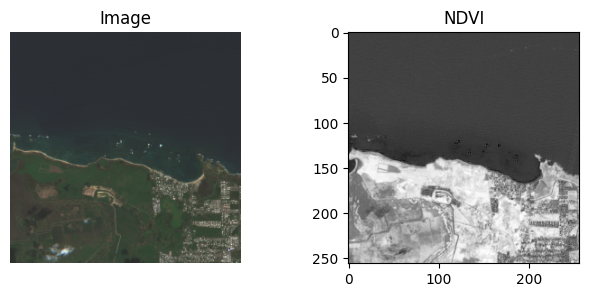

In [16]:
for i in range(3):
    name = samples[i]
    
    with rasterio.open(f"samples/{name}") as src:
        img = src.read()
    
    
    label_name = name.replace("img", "ndvi")
    with rasterio.open(f"labels/{label_name}") as src:
        lbl = src.read(1)
    
    plt.figure(figsize=(8,3))
    
    plt.subplot(1,2,1)
    plt.imshow(img.transpose(1,2,0))
    plt.title("Image")
    plt.axis("off")
    
    plt.subplot(1,2,2)
    plt.imshow(lbl, cmap='gray')
    plt.title("NDVI")
    
    plt.show()

NDVI = Remote sensing metric used to measure plant health and density by analyzing how plants reflect specific light waves. 

NDVI RANGE: 
< 0 = Water / snow / clouds
0 - 0.2 = Bair Soil / Rocks 
0.2 - 0.5 = Sparse Vegetation 
0.5 - 0.7 = Moderate Vegetation 
0.7 - 1.0 = Dense Vegetation 

In [ ]:
# Pixel Intensity Values
print("NDVI min:", np.min(lbl))
print("NDVI max:", np.max(lbl))
print("NDVI mean:", np.mean(lbl))

NDVI min: 113
NDVI max: 219
NDVI mean: 162.26670837402344


In [ ]:
# Converting the pixel intesity Values into actual NDVI Values
ndvi = (lbl / 255.0) * 2 - 1

print("Recovered NDVI min:", ndvi.min())
print("Recovered NDVI max:", ndvi.max())
print("Recovered NDVI mean:", ndvi.mean())

Recovered NDVI min: -0.2549019607843137
Recovered NDVI max: 0.7176470588235293
Recovered NDVI mean: 0.30972134459252454


In [ ]:
# NDVI interpretation function
def interpret_ndvi(mean_val):
    if mean_val < 0:
        return "Water / Snow / Clouds"
    elif mean_val < 0.2:
        return "Bare soil"
    elif mean_val < 0.5:
        return "Sparse vegetation"
    elif mean_val < 0.7:
        return "Moderate vegetation"
    else:
        return "Dense vegetation"

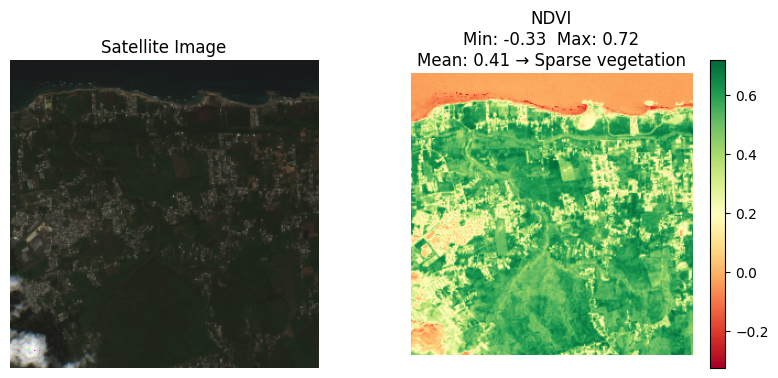

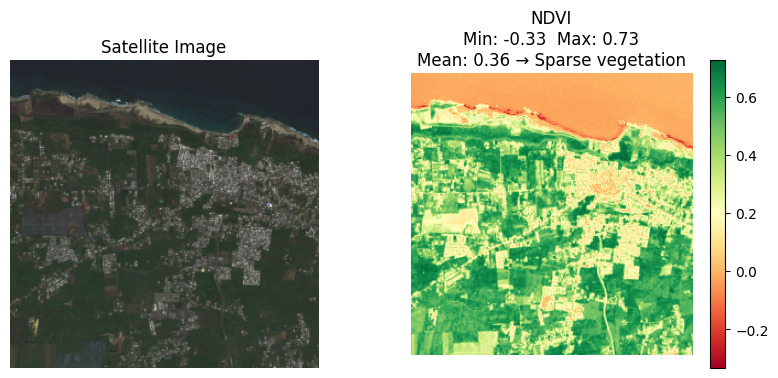

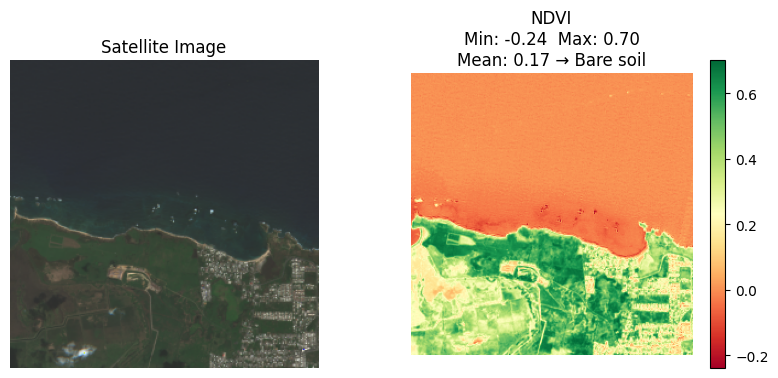

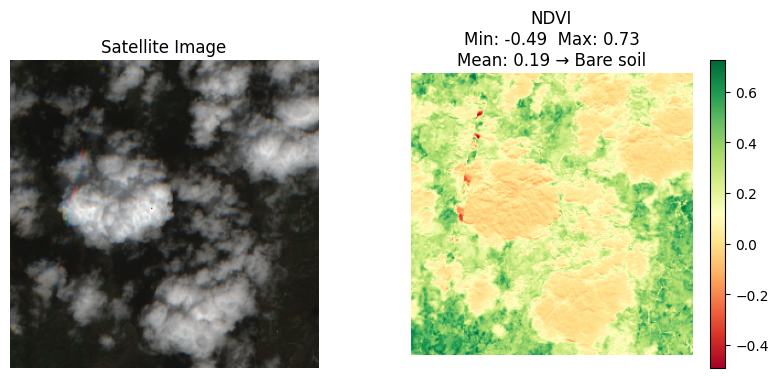

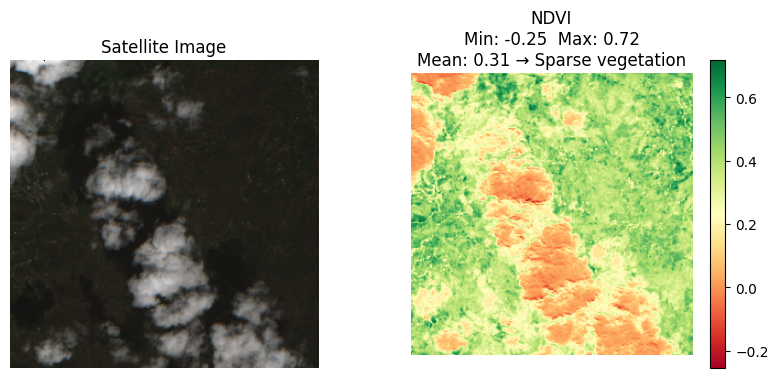

In [ ]:
samples = sorted(os.listdir("samples"))

for i in range(5):
    name = samples[i]
    
    with rasterio.open(f"samples/{name}") as src:
        img = src.read()
    
    label_name = name.replace("img", "ndvi")
    with rasterio.open(f"labels/{label_name}") as src:
        lbl = src.read(1)
    
    ndvi_min = np.min(ndvi)
    ndvi_max = np.max(ndvi)
    ndvi_mean = np.mean(ndvi)
    
    meaning = interpret_ndvi(ndvi_mean)
    
    plt.figure(figsize=(10,4))
    
    # Image
    plt.subplot(1,2,1)
    plt.imshow(img.transpose(1,2,0))
    plt.title("Satellite Image")
    plt.axis("off")
    
    # NDVI
    plt.subplot(1,2,2)
    plt.imshow(ndvi, cmap='RdYlGn')
    plt.colorbar()
    
    plt.title(
        f"NDVI\nMin: {ndvi_min:.2f}  Max: {ndvi_max:.2f}\n"
        f"Mean: {ndvi_mean:.2f} → {meaning}"
    )
    
    plt.axis("off")
    
    plt.show()

In [ ]:
# Checking the size of the samples and labels: 
print(img.shape)
print(lbl.shape) # Theyre already perfectly sized 

(3, 256, 256)
(256, 256)


In [ ]:
# No Values are missing
nan_count = 0

for name in samples:
    label_name = name.replace("img", "ndvi")
    with rasterio.open(f"labels/{label_name}") as src:
        lbl = src.read(1)
        if np.isnan(lbl).any():
            nan_count += 1

print("Labels with NaN values:", nan_count)

Labels with NaN values: 0
